# Revisão Aula 1 + Aula 2 — laboratório de 15 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-revisao-a1-a2.ipynb)

**Trilha de Trainees — InsperAI** · revisão das aulas [1](https://trilhas-insperai.vercel.app/trainees/aulas/aula-01/) e [2](https://trilhas-insperai.vercel.app/trainees/aulas/aula-02/)

---

**Como usar:** rode as células na ordem, de cima pra baixo. Não precisa escrever código do zero.
Em três lugares tem um `# MUDE AQUI` pra você mexer num número e rodar de novo.
O que importa é o que acontece com os números e os gráficos quando você mexe.

Cada seção termina com uma pergunta. Anota a resposta, a gente discute no final.

## 0. Setup — roda e segue

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# O mesmo dataset da lousa
metragem = np.array([ 30.,  55.,  80., 110., 150.])
quartos  = np.array([  1.,   2.,   2.,   3.,   4.])
idade    = np.array([ 20.,  15.,   5.,  10.,   2.])
preco    = np.array([140., 215., 290., 380., 500.])
nomes    = ['A', 'B', 'C', 'D', 'E']

x = metragem   # atalho: a feature única da Aula 1
y = preco

for n, m, q, i, p in zip(nomes, metragem, quartos, idade, preco):
    print(f'{n}  {m:6.0f} m²  {q:.0f} quartos  {i:2.0f} anos   R$ {p:.0f} mil')

A      30 m²  1 quartos  20 anos   R$ 140 mil
B      55 m²  2 quartos  15 anos   R$ 215 mil
C      80 m²  2 quartos   5 anos   R$ 290 mil
D     110 m²  3 quartos  10 anos   R$ 380 mil
E     150 m²  4 quartos   2 anos   R$ 500 mil


## 1. Quanto custa um modelo ruim?

O modelo é `previsão = w * metragem + b`. Aqui embaixo estão os pesos chutados que a gente usou na
lousa: `w = 2`, `b = 100`. As três funções de custo estão calculadas lado a lado.

In [2]:
def custos(w, b):
    pred = w * x + b
    erro = pred - y
    mae  = np.abs(erro).mean()
    mse  = (erro ** 2).mean()
    rmse = np.sqrt(mse)
    print(f'w = {w},  b = {b}')
    print(f'{"apto":<6}{"real":>8}{"previsto":>11}{"erro":>9}{"erro²":>10}')
    for n, real, p, e in zip(nomes, y, pred, erro):
        print(f'{n:<6}{real:>8.0f}{p:>11.1f}{e:>9.1f}{e**2:>10.1f}')
    print(f'\nMAE  = {mae:8.2f}   (erro médio, em mil R$)')
    print(f'MSE  = {mse:8.2f}   (não está em mil R$, está em "mil R$ ao quadrado")')
    print(f'RMSE = {rmse:8.2f}   (voltou pra mil R$)')
    return erro

erro = custos(w=2, b=100)   # MUDE AQUI: tente achar w e b que zerem o custo

w = 2,  b = 100
apto      real   previsto     erro     erro²
A          140      160.0     20.0     400.0
B          215      210.0     -5.0      25.0
C          290      260.0    -30.0     900.0
D          380      320.0    -60.0    3600.0
E          500      400.0   -100.0   10000.0

MAE  =    43.00   (erro médio, em mil R$)
MSE  =  2985.00   (não está em mil R$, está em "mil R$ ao quadrado")
RMSE =    54.64   (voltou pra mil R$)


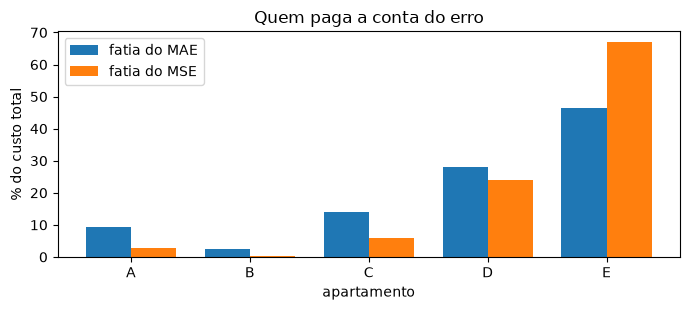

O apto E responde por 47% do MAE e 67% do MSE.


In [3]:
# De onde vem o custo? Quanto cada apartamento contribui pro total.
parte_mae = np.abs(erro) / np.abs(erro).sum()
parte_mse = erro**2 / (erro**2).sum()

fig, ax = plt.subplots(figsize=(7, 3.2))
larg = 0.38
pos = np.arange(len(nomes))
ax.bar(pos - larg/2, parte_mae*100, larg, label='fatia do MAE')
ax.bar(pos + larg/2, parte_mse*100, larg, label='fatia do MSE')
ax.set_xticks(pos); ax.set_xticklabels(nomes)
ax.set_ylabel('% do custo total'); ax.set_xlabel('apartamento')
ax.set_title('Quem paga a conta do erro')
ax.legend(); plt.tight_layout(); plt.show()

print(f'O apto E responde por {parte_mae[-1]*100:.0f}% do MAE e {parte_mse[-1]*100:.0f}% do MSE.')

**Pergunta 1.** O apto E é o que mais erra. No MAE ele vale menos da metade do custo, no MSE ele vale
dois terços. Se um dos cinco apartamentos fosse um erro de digitação no dataset (um preço absurdo que
não deveria estar ali), qual das duas funções de custo te daria um modelo menos estragado por ele?

## 2. Gradient descent na metragem crua

Agora a gente não chuta mais. O gradient descent começa em `w = 0`, `b = 0` e vai descendo sozinho.
Cada passo mexe nos dois ao mesmo tempo, com a mesma taxa de aprendizado.

60 passos, alpha = 0,00005:  w = 3.4724   b = 0.0622
(era isso que estava na lousa)

2000 passos, alpha = 0,0002: w = 3.4371   (alvo: 3)
                             b = 3.7982   (alvo: 50)


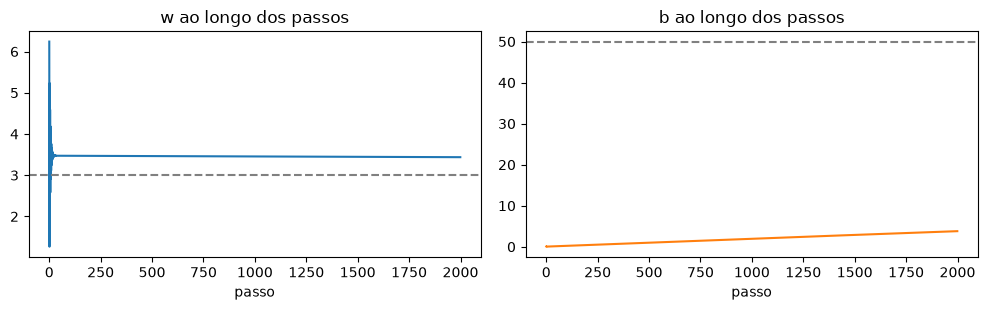

In [4]:
def gradient_descent(X, Y, alpha, n_passos, w=0.0, b=0.0):
    hist_w, hist_b, hist_custo = [], [], []
    for _ in range(n_passos):
        erro = w * X + b - Y
        grad_w = (erro * X).mean()
        grad_b = erro.mean()
        w -= alpha * grad_w
        b -= alpha * grad_b
        hist_w.append(w); hist_b.append(b); hist_custo.append((erro**2).mean())
    return w, b, np.array(hist_w), np.array(hist_b), np.array(hist_custo)

# Primeiro, os mesmos 60 passos que a gente fez na lousa (alpha = 0,00005)
w60, b60, _, _, _ = gradient_descent(x, y, alpha=0.00005, n_passos=60)
print(f'60 passos, alpha = 0,00005:  w = {w60:.4f}   b = {b60:.4f}')
print('(era isso que estava na lousa)\n')

# Agora com bem mais passos e o maior alpha que ainda funciona
w_f, b_f, hw, hb, hc = gradient_descent(x, y, alpha=0.0002, n_passos=2000)
print(f'2000 passos, alpha = 0,0002: w = {w_f:.4f}   (alvo: 3)')
print(f'                             b = {b_f:.4f}   (alvo: 50)')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(hw); ax[0].axhline(3, ls='--', c='gray'); ax[0].set_title('w ao longo dos passos')
ax[1].plot(hb, c='tab:orange'); ax[1].axhline(50, ls='--', c='gray'); ax[1].set_title('b ao longo dos passos')
for a in ax: a.set_xlabel('passo')
plt.tight_layout(); plt.show()

**Pergunta 2.** Os dois gráficos têm o mesmo eixo x e a mesma taxa de aprendizado. Por que o `w`
praticamente chega no valor certo e o `b` mal saiu do lugar? Olhe o tamanho dos números que multiplicam
cada um deles no cálculo do gradiente.

## 3. A taxa de aprendizado

Mesmo modelo, mesma inicialização, só muda o `alpha`. Repare no eixo y de cada gráfico.

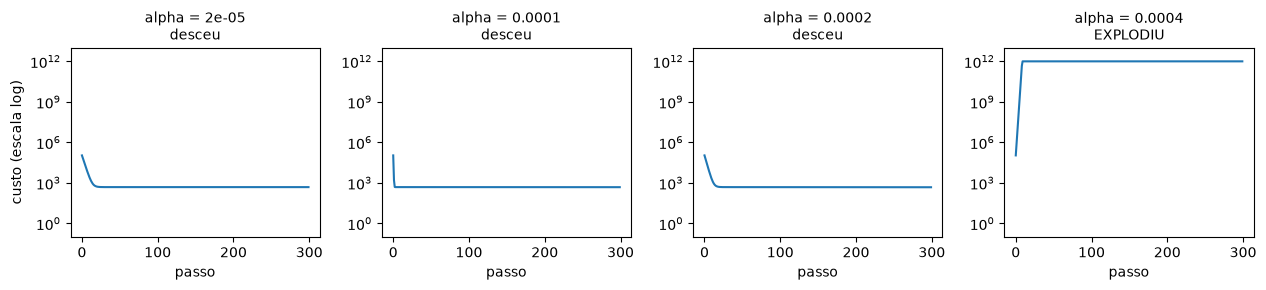

alpha = 2e-05      custo:    108,865 -> 487.92         
alpha = 0.0001     custo:    108,865 -> 483.37         
alpha = 0.0002     custo:    108,865 -> 477.74         
alpha = 0.0004     custo:    108,865 -> 4.2e+252       o passo é grande demais, ele pula pro outro lado do vale e sobe


In [5]:
alphas = [0.00002, 0.0001, 0.0002, 0.0004]   # MUDE AQUI: acrescente 0.001 e veja o que acontece

fig, axes = plt.subplots(1, len(alphas), figsize=(3.2*len(alphas), 3))
axes = np.atleast_1d(axes)
resumo = []
for a, eixo in zip(alphas, axes):
    _, _, _, _, custo = gradient_descent(x, y, alpha=a, n_passos=300)
    limpo = np.where(np.isfinite(custo) & (custo > 0), custo, np.nan)
    explodiu = not np.isfinite(custo[-1]) or custo[-1] > custo[0]
    eixo.plot(np.clip(limpo, 1e-2, 1e12))
    eixo.set_yscale('log'); eixo.set_ylim(1e-1, 1e13)
    eixo.set_title(f'alpha = {a}\n{"EXPLODIU" if explodiu else "desceu"}', fontsize=10)
    eixo.set_xlabel('passo')
    resumo.append((a, custo[0], custo[-1], explodiu))
axes[0].set_ylabel('custo (escala log)')
plt.tight_layout(); plt.show()

for a, ini, fim, explodiu in resumo:
    if not np.isfinite(fim):
        fim_txt = 'infinito'
    else:
        fim_txt = f'{fim:.1e}' if fim > 1e6 else f'{fim:,.2f}'
    print(f'alpha = {a:<10} custo: {ini:>10,.0f} -> {fim_txt:<14} '
          f'{"o passo é grande demais, ele pula pro outro lado do vale e sobe" if explodiu else ""}')

**Pergunta 3.** Existe um alpha grande demais e um alpha pequeno demais. Descreve com suas palavras o
que dá errado em cada um dos dois casos.

## 4. A mesma conta, com a metragem padronizada

Aqui está o ponto da aula inteira. Nada muda no modelo e nada muda no algoritmo. A única coisa que muda
é a régua da coluna metragem.

In [6]:
media = metragem.mean()
desvio = metragem.std()
x_pad = (metragem - media) / desvio

print(f'média = {media:.2f}   desvio = {desvio:.2f}')
print('metragem crua       :', metragem)
print('metragem padronizada:', np.round(x_pad, 3))

média = 85.00   desvio = 41.95
metragem crua       : [ 30.  55.  80. 110. 150.]
metragem padronizada: [-1.311 -0.715 -0.119  0.596  1.549]


In [7]:
def passos_ate_convergir(X, Y, alpha, tol=1e-3, maximo=1_000_000):
    w = b = 0.0
    for i in range(1, maximo + 1):
        erro = w * X + b - Y
        gw = (erro * X).mean(); gb = erro.mean()
        w -= alpha * gw; b -= alpha * gb
        if not np.isfinite(w):
            return None, i
        if np.hypot(gw, gb) < tol:
            return (w, b), i
    return (w, b), maximo

res_cru, n_cru = passos_ate_convergir(metragem, y, alpha=0.0002)
res_pad, n_pad = passos_ate_convergir(x_pad,    y, alpha=0.5)

print(f'metragem crua        : {n_cru:>8} passos  (com o maior alpha que não explode)')
print(f'metragem padronizada : {n_pad:>8} passos')
print(f'\ndiferença: {n_cru/n_pad:,.0f}x')

# E o modelo achado é o mesmo? Desfazendo a padronização:
w_pad, b_pad = res_pad
w_orig = w_pad / desvio
b_orig = b_pad - w_pad * media / desvio
print(f'\nno espaço padronizado: w = {w_pad:.2f}, b = {b_pad:.2f}   (números estranhos)')
print(f'traduzido de volta   : w = {w_orig:.4f}, b = {b_orig:.4f}   (o mesmo modelo de sempre)')

metragem crua        :   234568 passos  (com o maior alpha que não explode)
metragem padronizada :       20 passos

diferença: 11,728x

no espaço padronizado: w = 125.86, b = 305.00   (números estranhos)
traduzido de volta   : w = 3.0000, b = 50.0000   (o mesmo modelo de sempre)


**Pergunta 4.** Padronizar não mudou o modelo final, mudou o caminho até ele. Então o que exatamente a
padronização conserta: o modelo ou o treino? E por que essa distinção importa?

## 5. Bônus: mesma regressão, coluna fabricada

Regressão polinomial não é outro algoritmo. É a mesma regressão linear com uma coluna `x²`, `x³` e por aí
vai. Aqui um dataset maior e com ruído, porque com 5 pontos perfeitos não dá pra ver overfitting.

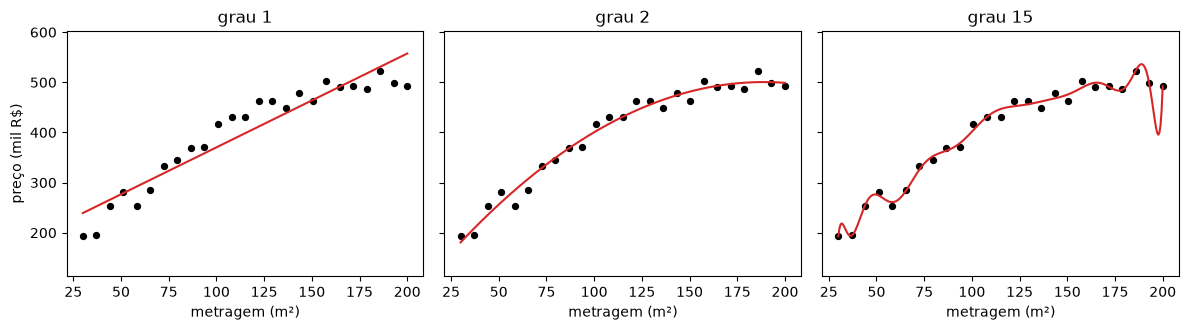

In [8]:
rng = np.random.default_rng(42)
m2 = np.linspace(30, 200, 25)
preco_real = -0.012 * m2**2 + 4.6 * m2 + 60          # retorno decrescente
preco_obs = preco_real + rng.normal(0, 18, size=m2.size)   # ruído do mundo real

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
grade = np.linspace(30, 200, 300)
for grau, eixo in zip([1, 2, 15], axes):
    coef = np.polyfit(m2, preco_obs, grau)
    eixo.scatter(m2, preco_obs, s=18, c='k', label='dados')
    eixo.plot(grade, np.polyval(coef, grade), c='tab:red', label=f'grau {grau}')
    eixo.set_title(f'grau {grau}'); eixo.set_xlabel('metragem (m²)')
    eixo.set_ylim(preco_obs.min()-80, preco_obs.max()+80)
axes[0].set_ylabel('preço (mil R$)')
plt.tight_layout(); plt.show()

**Pergunta 5.** O modelo de grau 15 passa muito mais perto dos pontos pretos que o de grau 2. O custo
dele no dataset de treino é menor. Mesmo assim ele é o pior dos três. Por quê?

Isso é o assunto da Aula 7. Guarda a pergunta.

---

### Desafio, se sobrar tempo

Volta na seção 4 e padroniza a coluna **quartos** também. Treina um modelo com duas features
(metragem e quartos) e compara quantos passos leva com e sem padronizar. Dica: `w` vira um vetor e a
previsão vira `X @ w + b`.

<details><summary>Resposta</summary>

Primeiro, por que não dá pra reaproveitar o `passos_ate_convergir` da seção 4: lá dentro `w` é um
**número**, e `grad_w = (erro * X).mean()` devolve outro número. Com duas colunas você precisa de um
gradiente **por coluna**. É a única mudança de verdade — o resto do algoritmo é idêntico:

```python
def passos_ate_convergir_multi(X, Y, alpha, tol=1e-3, maximo=1_000_000):
    w = np.zeros(X.shape[1])     # um peso por coluna, em vez de um número
    b = 0.0
    for i in range(1, maximo + 1):
        erro   = X @ w + b - Y        # (n_amostras,) — a previsão de todo mundo de uma vez
        grad_w = X.T @ erro / len(Y)  # (n_features,) — um gradiente por coluna
        grad_b = erro.mean()
        w -= alpha * grad_w
        b -= alpha * grad_b
        if not np.isfinite(w).all():
            return None, i
        if np.hypot(np.linalg.norm(grad_w), grad_b) < tol:
            return (w, b), i
    return (w, b), maximo

# As duas features cruas, uma por coluna
X_cru = np.column_stack([metragem, quartos])

# COMPLETE AQUI: a mesma matriz, com as duas colunas padronizadas.
# Cuidado: a padronização é por coluna — cada uma tem a sua própria média e o seu
# próprio desvio. Na seção 4 isso era um par de números; agora é um par por coluna.
X_pad = ...

res_cru, n_cru = passos_ate_convergir_multi(X_cru, y, alpha=0.0002)   # o maior que não explode
res_pad, n_pad = passos_ate_convergir_multi(X_pad, y, alpha=0.5)
print(f'cruas       : {n_cru:>8} passos')
print(f'padronizadas: {n_pad:>8} passos')
```

**O que você deve ver** (com `X.std(axis=0)`, o mesmo desvio da seção 4):

- **Cruas, alpha = 0,0002:** estoura o teto de **1.000.000 de passos sem convergir**. Ele chega perto
  do alvo — `w = [2,999  0,029]`, `b = 49,99` — mas o critério de parada não é atingido. Com uma
  feature só eram 234.568 passos; a segunda coluna piorou o condicionamento e o custo explodiu junto.
  E `alpha = 0,0004` continua explodindo, então não dá pra compensar acelerando.
- **Padronizadas, alpha = 0,5: 806 passos.**

Duas coisas que valem mais que o número:

**O peso de `quartos` sai ~0.** A solução exata é `w = [3, 0]`, `b = 50` — porque o dataset *é*
`3 × metragem + 50`. `quartos` tem correlação de 0,98 com `metragem`: ele não traz informação nova, só
repete a que já estava lá. É o quiz da Aula 2 acontecendo no seu terminal — feature a mais não é
feature melhor.

**Padronizar não conserta tudo.** Com uma feature, padronizada, eram **20** passos; com duas, **806**.
A escala deixou de ser o problema, mas as duas colunas continuam quase paralelas, e um vale comprido
e estreito continua comprido e estreito. Escala e colinearidade são doenças diferentes.

</details>
